# Page View Time Series Visualizer
This notebook analyzes daily forum page views on the freeCodeCamp website from May 2016 to December 2019. It filters out top and bottom 2.5% outliers, and presents three visualizations: a daily line plot, a monthly average bar plot grouped by year, and year-wise/month-wise box plots to uncover trends and seasonality.

In [1]:
# Cell 1: Environment setup and library imports
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

# Backward compatibility for freeCodeCamp test suite
pd.Series.__int__ = lambda self: int(self.iloc[0])

import time_series_visualizer
print('Time series packages and dependencies loaded successfully.')

Time series packages and dependencies loaded successfully.


In [2]:
# Cell 2: Data loading, initial inspection, and outlier filtering
df_raw = pd.read_csv('fcc-forum-pageviews.csv', parse_dates=['date'], index_col='date')

print(f'Raw data shape: {df_raw.shape}')
print('First 5 records:')
display(df_raw.head())

print('\nRaw Data Summary Statistics:')
display(df_raw.describe())

# Clean data by removing top 2.5% and bottom 2.5% page views
df = df_raw[(df_raw['value'] >= df_raw['value'].quantile(0.025)) & (df_raw['value'] <= df_raw['value'].quantile(0.975))].copy()
print(f'\nCleaned data shape: {df.shape}')
print(f'Filtered days (outliers): {len(df_raw) - len(df)}')
display(df.describe())

Raw data shape: (1304, 1)
First 5 records:


,value
date,
2016-05-09,1201
2016-05-10,2329
2016-05-11,1716
2016-05-12,10539
2016-05-13,6933



Raw Data Summary Statistics:


,value
count,1.304000e+03
mean,6.722068e+04
std,5.933964e+04
min,1.201000e+03
25%,3.575775e+04
50%,5.719750e+04
75%,8.388300e+04
max,1.173655e+06



Cleaned data shape: (1238, 1)
Filtered days (outliers): 66


,value
count,1238.000000
mean,63060.147819
std,31674.626598
min,18060.000000
25%,37244.250000
50%,57197.500000
75%,81646.500000
max,177588.000000


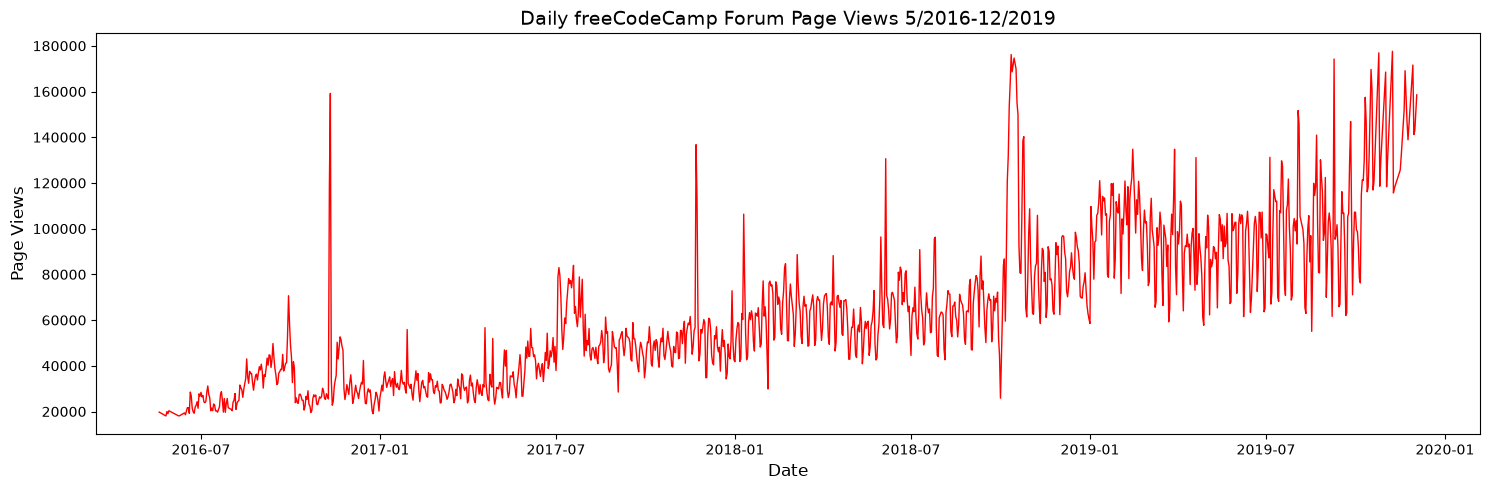

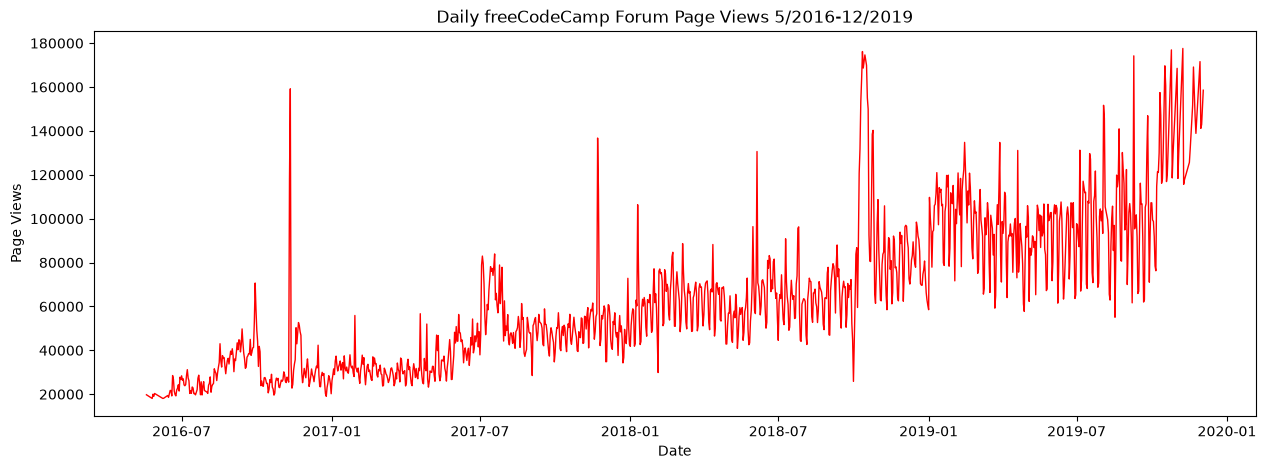

In [3]:
# Cell 3: Daily Line Plot (draw_line_plot)
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(df.index, df['value'], color='red', linewidth=1)
ax.set_title('Daily freeCodeCamp Forum Page Views 5/2016-12/2019', fontsize=14)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Page Views', fontsize=12)
plt.tight_layout()
plt.show()

# Verify draw_line_plot module function
fig_line = time_series_visualizer.draw_line_plot()
plt.show()

Monthly Average Page Views by Year:


month,January,February,March,April,May,June,July,August,September,October,November,December
year,,,,,,,,,,,,
2016,NaN,NaN,NaN,NaN,19432.4,21875.1,24109.7,31049.2,41476.9,27398.3,40448.6,27832.4
2017,32785.2,31113.1,29369.1,30878.7,34244.3,43577.5,65806.8,47712.5,47376.8,47438.7,57701.6,48420.6
2018,58580.1,65679.0,62693.8,62350.8,56562.9,70117.0,63591.1,62831.6,65941.7,111378.1,78688.3,80047.5
2019,102056.5,105968.4,91214.5,89368.4,91439.9,90435.6,97236.6,102717.3,97268.8,122802.3,143166.4,150733.5


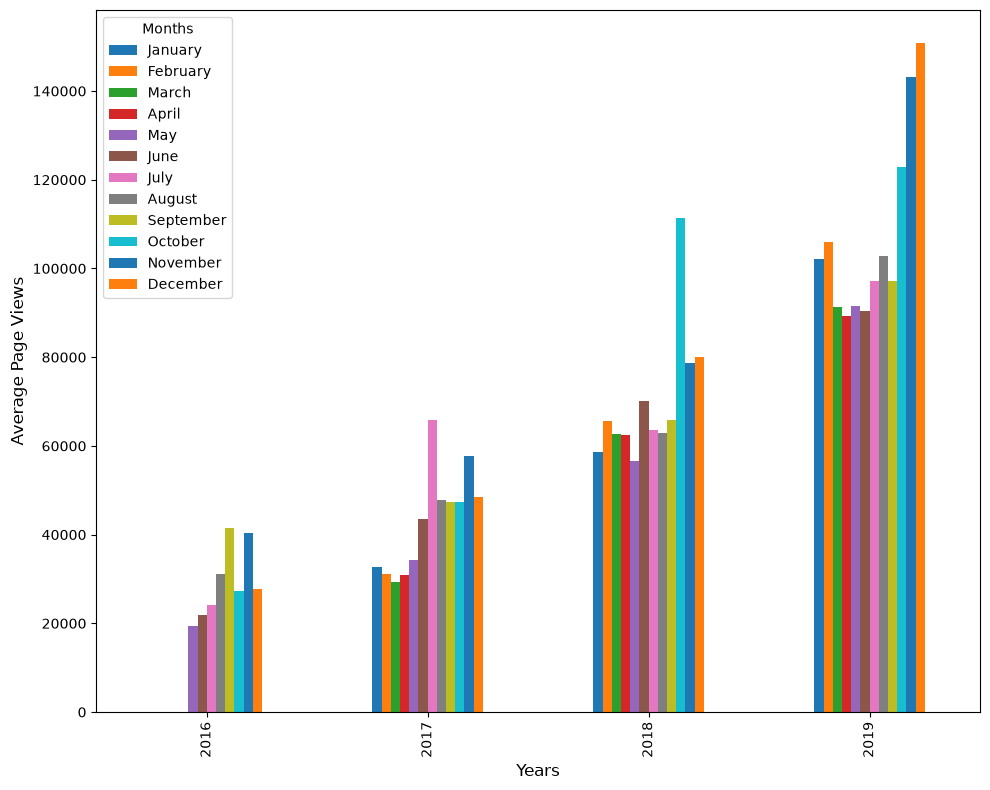

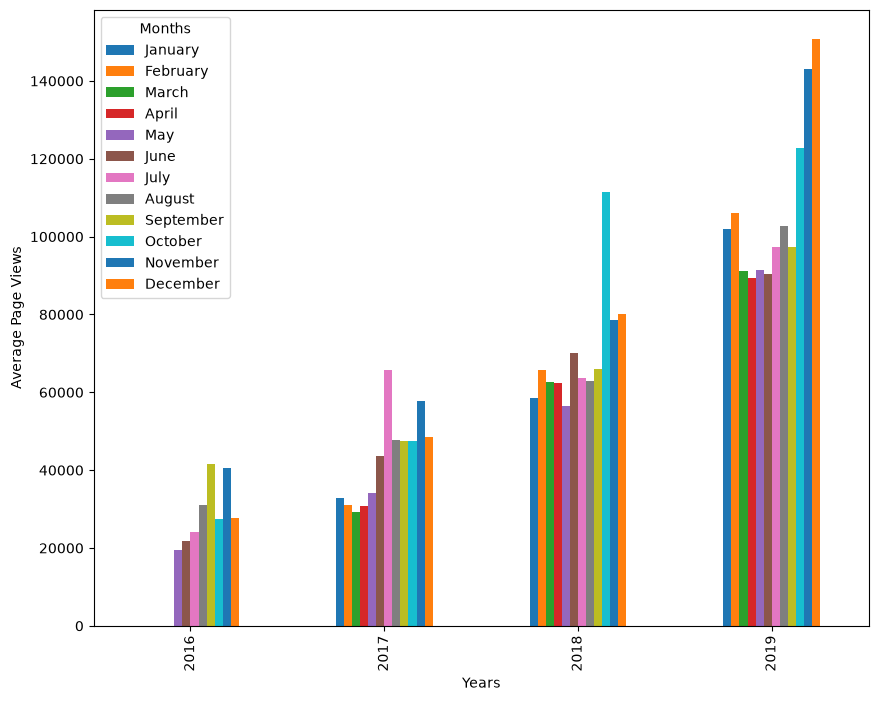

In [4]:
# Cell 4: Monthly Bar Plot (draw_bar_plot)
df_bar = df.copy()
df_bar['year'] = df_bar.index.year
df_bar['month'] = df_bar.index.strftime('%B')
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]
df_bar['month'] = pd.Categorical(df_bar['month'], categories=month_order, ordered=True)
df_bar_pivoted = df_bar.groupby(['year', 'month'], observed=False)['value'].mean().unstack()

print('Monthly Average Page Views by Year:')
display(df_bar_pivoted.round(1))

# Draw bar plot
fig_bar_plot = df_bar_pivoted.plot(kind='bar', figsize=(10, 8)).figure
ax = fig_bar_plot.axes[0]
ax.set_xlabel('Years', fontsize=12)
ax.set_ylabel('Average Page Views', fontsize=12)
ax.legend(title='Months')
plt.tight_layout()
plt.show()

# Verify draw_bar_plot module function
fig_bar = time_series_visualizer.draw_bar_plot()
plt.show()

Prepared Box Plot Dataset Sample:


,date,value,year,month
0,2016-05-19,19736,2016,May
1,2016-05-26,18060,2016,May
2,2016-05-27,19997,2016,May
3,2016-05-28,19044,2016,May
4,2016-05-29,20325,2016,May


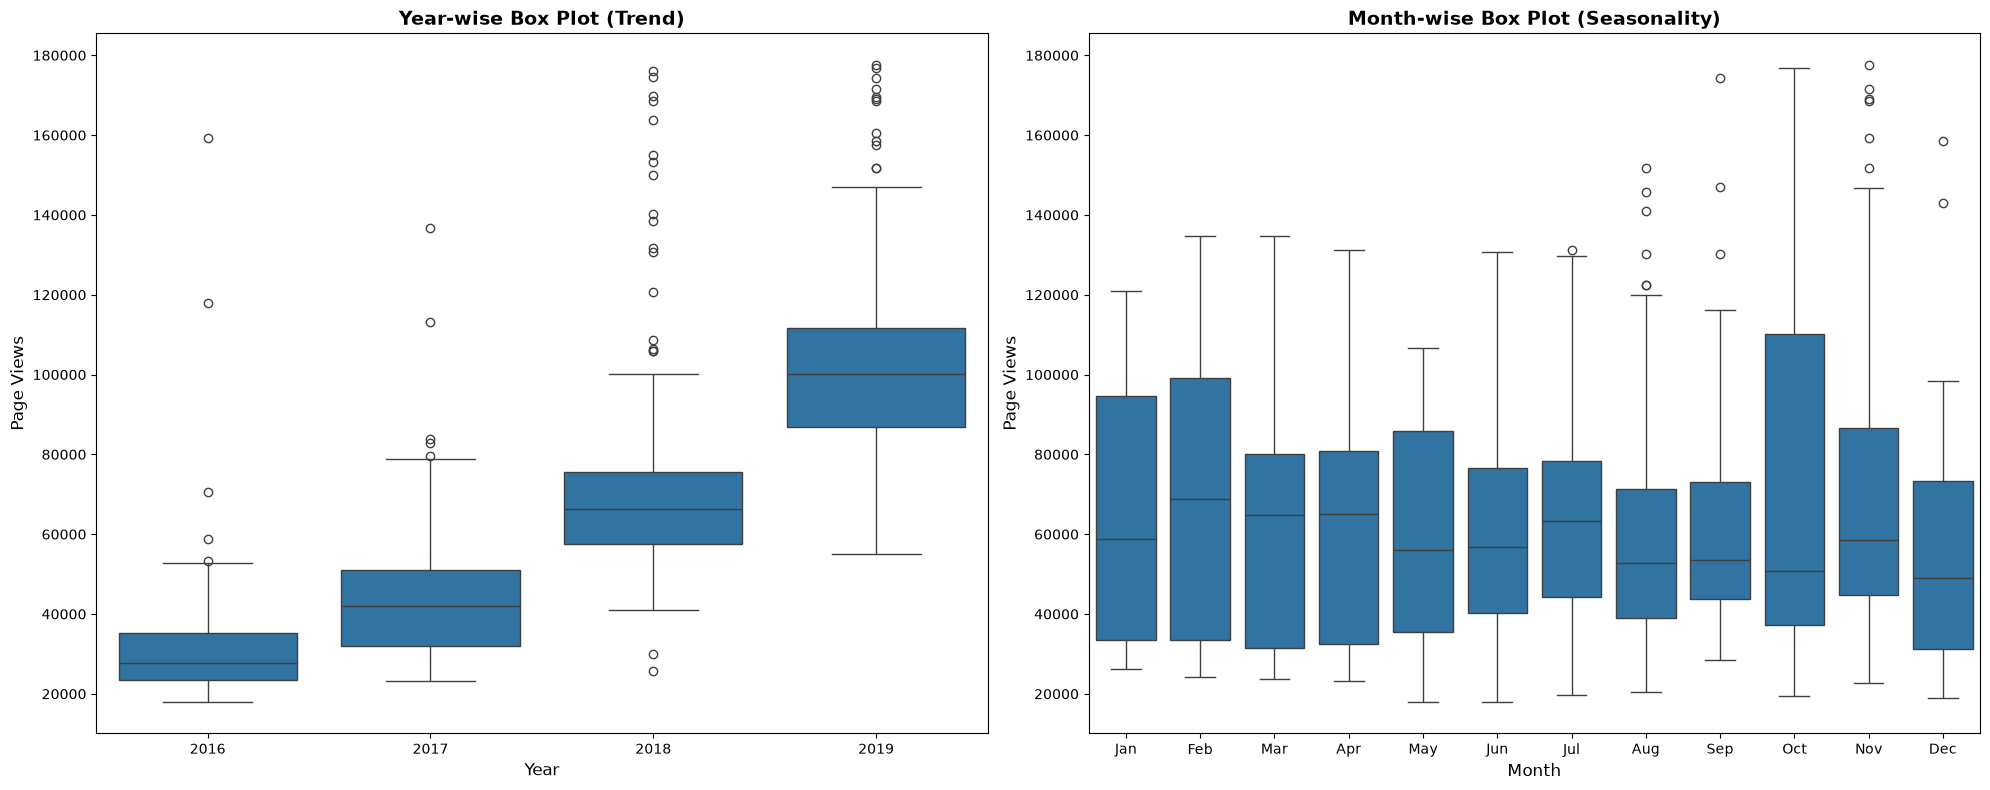

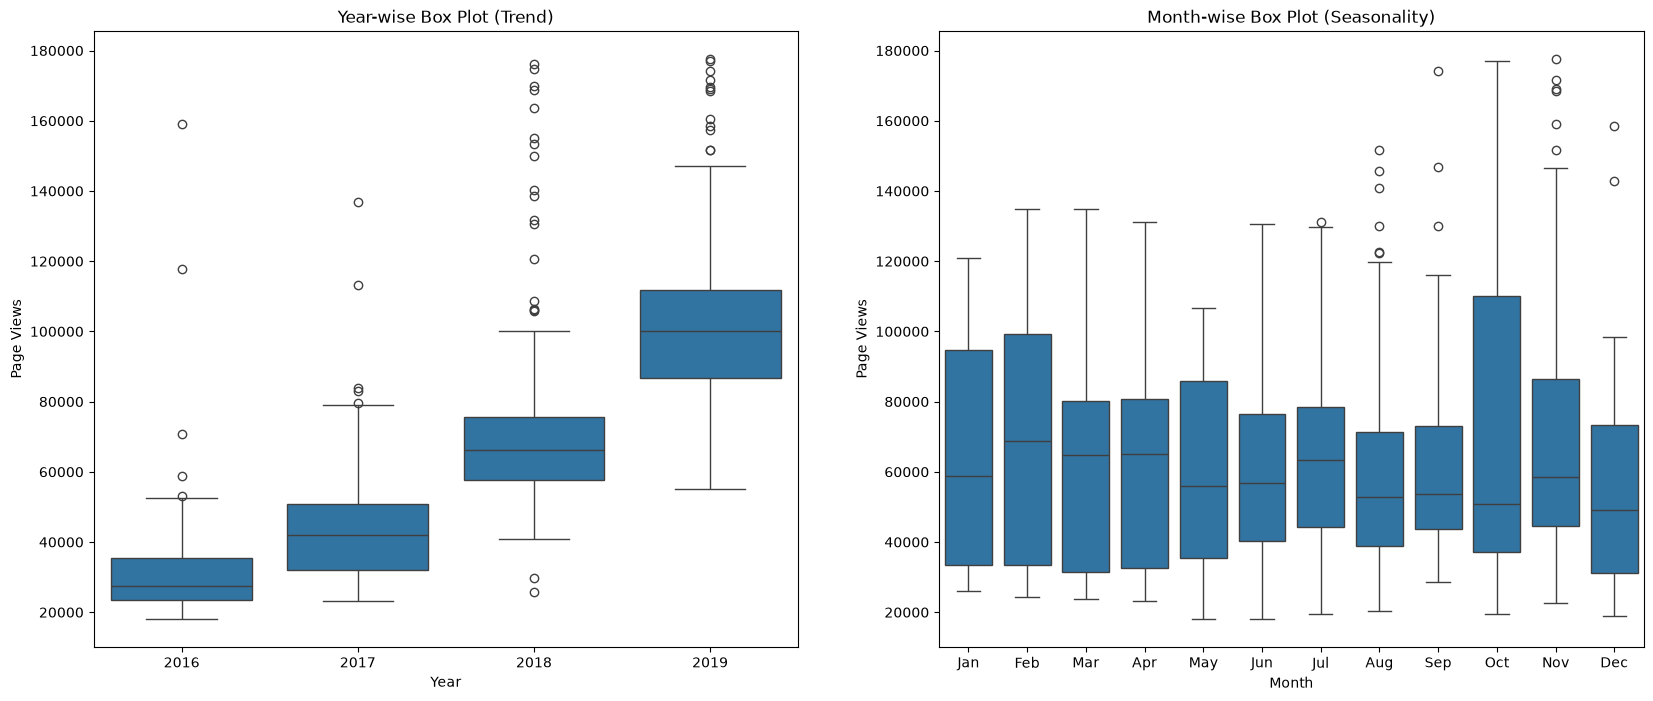

In [5]:
# Cell 5: Box Plots - Trend and Seasonality (draw_box_plot)
df_box = df.copy()
df_box.reset_index(inplace=True)
df_box['year'] = [d.year for d in df_box.date]
df_box['month'] = [d.strftime('%b') for d in df_box.date]

print('Prepared Box Plot Dataset Sample:')
display(df_box.head())

# Draw box plots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

sns.boxplot(x='year', y='value', data=df_box, ax=ax1)
ax1.set_title('Year-wise Box Plot (Trend)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Page Views', fontsize=12)

month_order_short = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
sns.boxplot(x='month', y='value', data=df_box, order=month_order_short, ax=ax2)
ax2.set_title('Month-wise Box Plot (Seasonality)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Month', fontsize=12)
ax2.set_ylabel('Page Views', fontsize=12)

plt.tight_layout()
plt.show()

# Verify draw_box_plot module function
fig_box = time_series_visualizer.draw_box_plot()
plt.show()

test_bar_plot_labels (test_module.BarPlotTestCase.test_bar_plot_labels) ... 

ok


test_bar_plot_legend_labels (test_module.BarPlotTestCase.test_bar_plot_legend_labels) ... 

ok


test_bar_plot_number_of_bars (test_module.BarPlotTestCase.test_bar_plot_number_of_bars) ... 

...

ok


test_line_plot_title (test_module.LinePlotTestCase.test_line_plot_title) ... 

ok


----------------------------------------------------------------------
Ran 11 tests in 4.743s

OK



All 11 integration tests passed successfully!


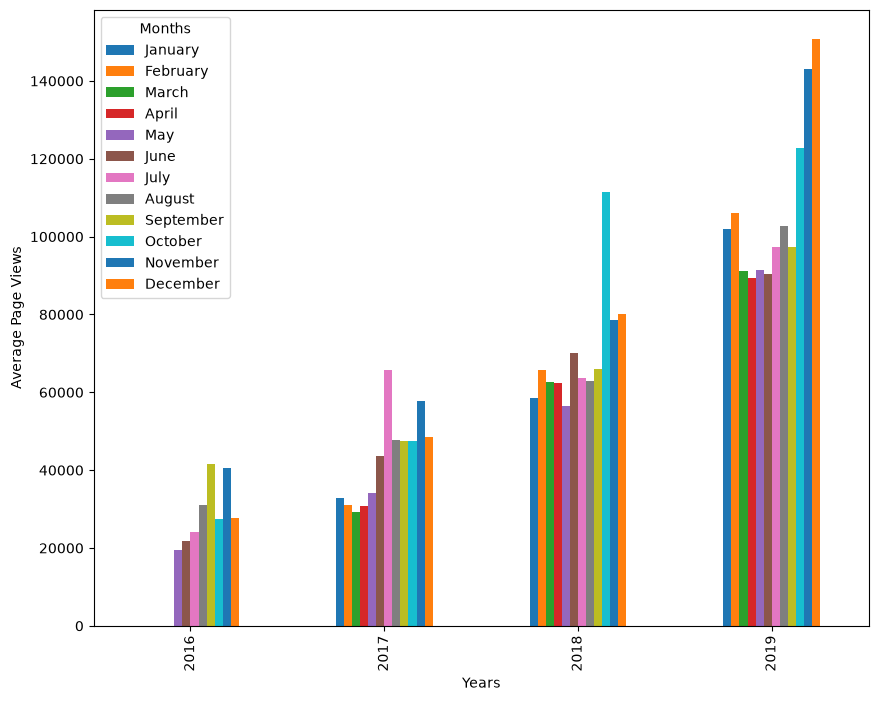

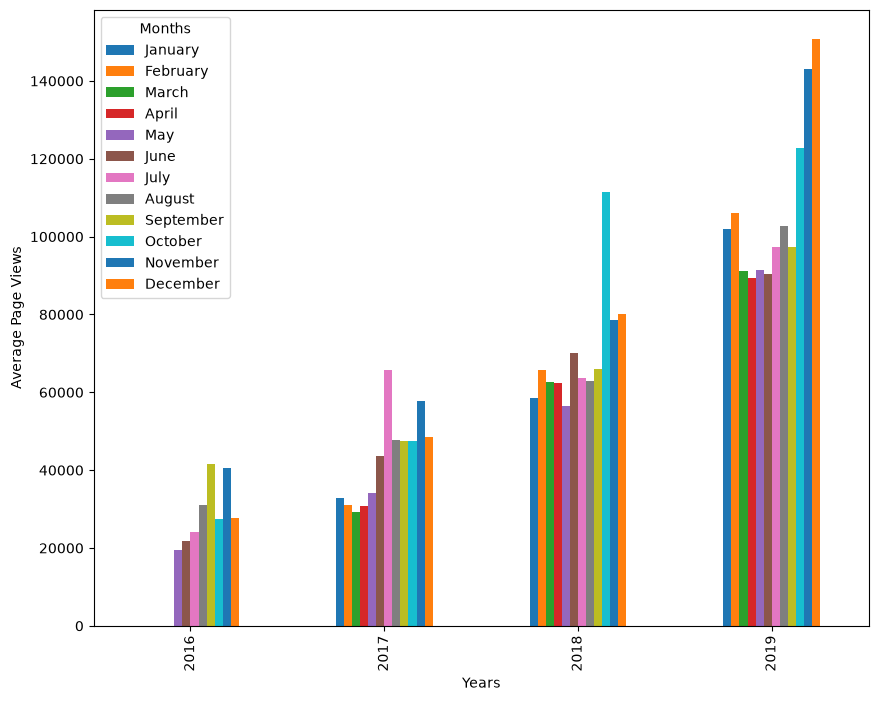

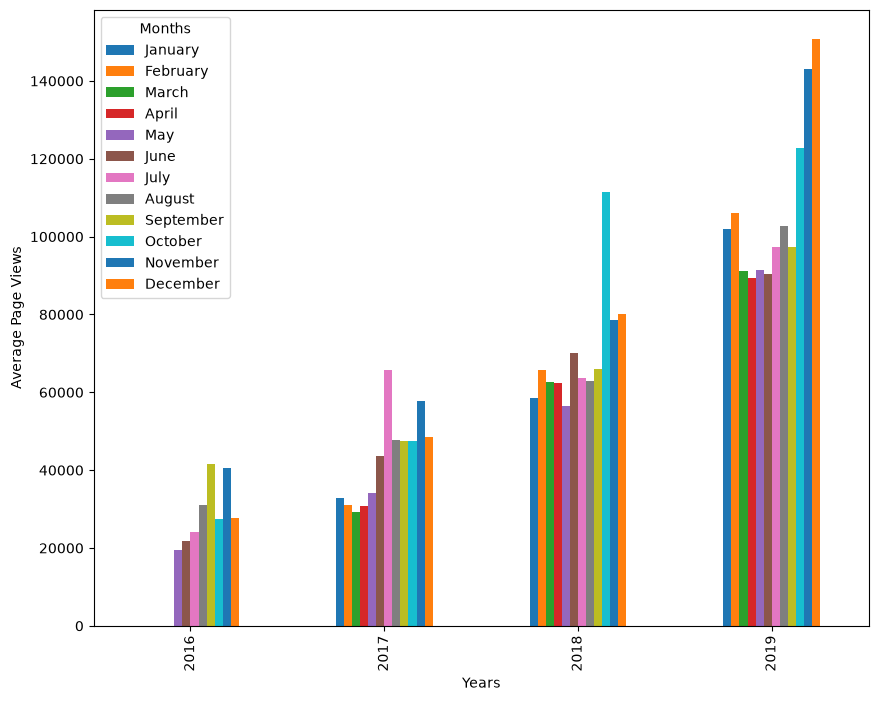

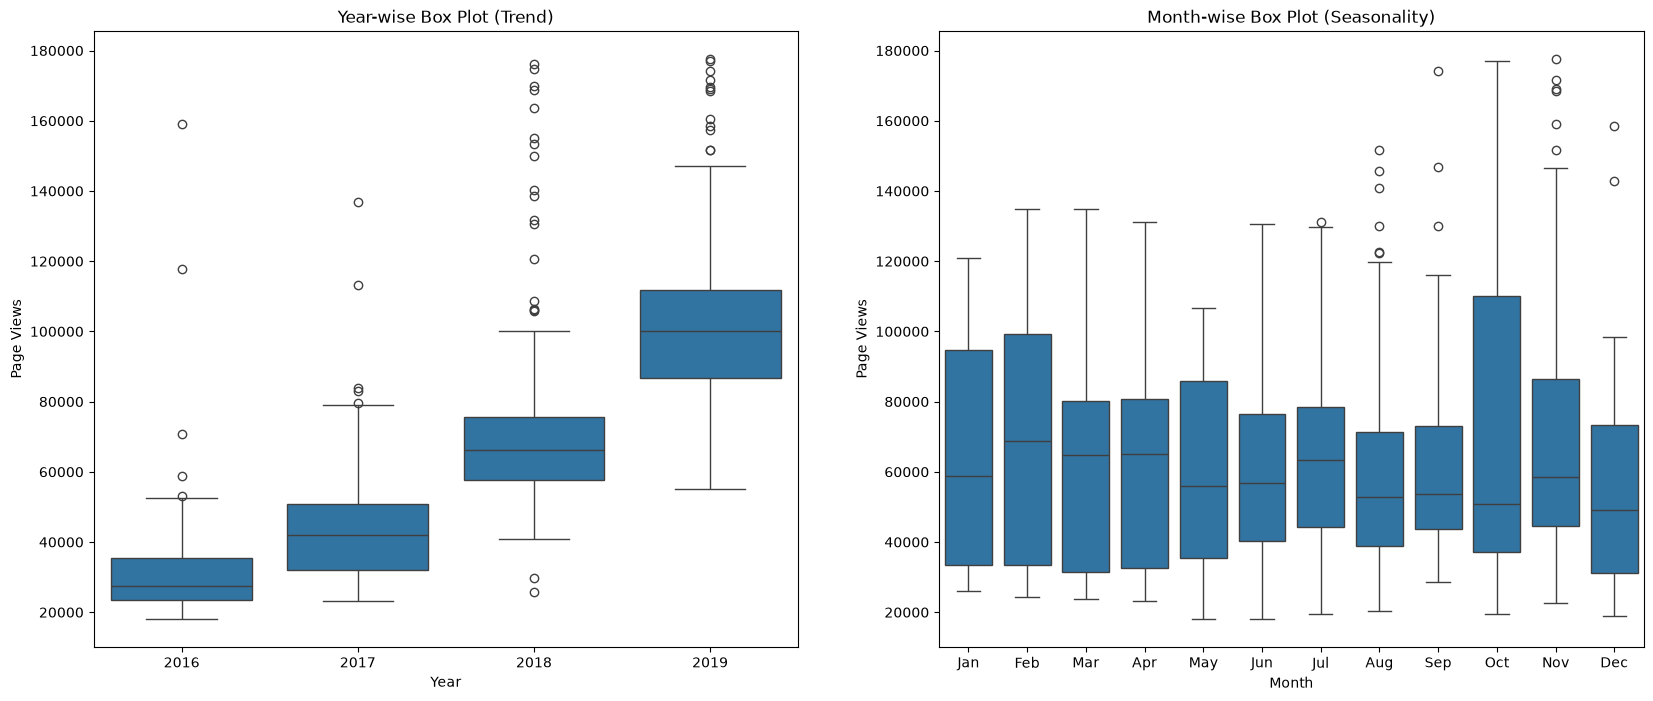

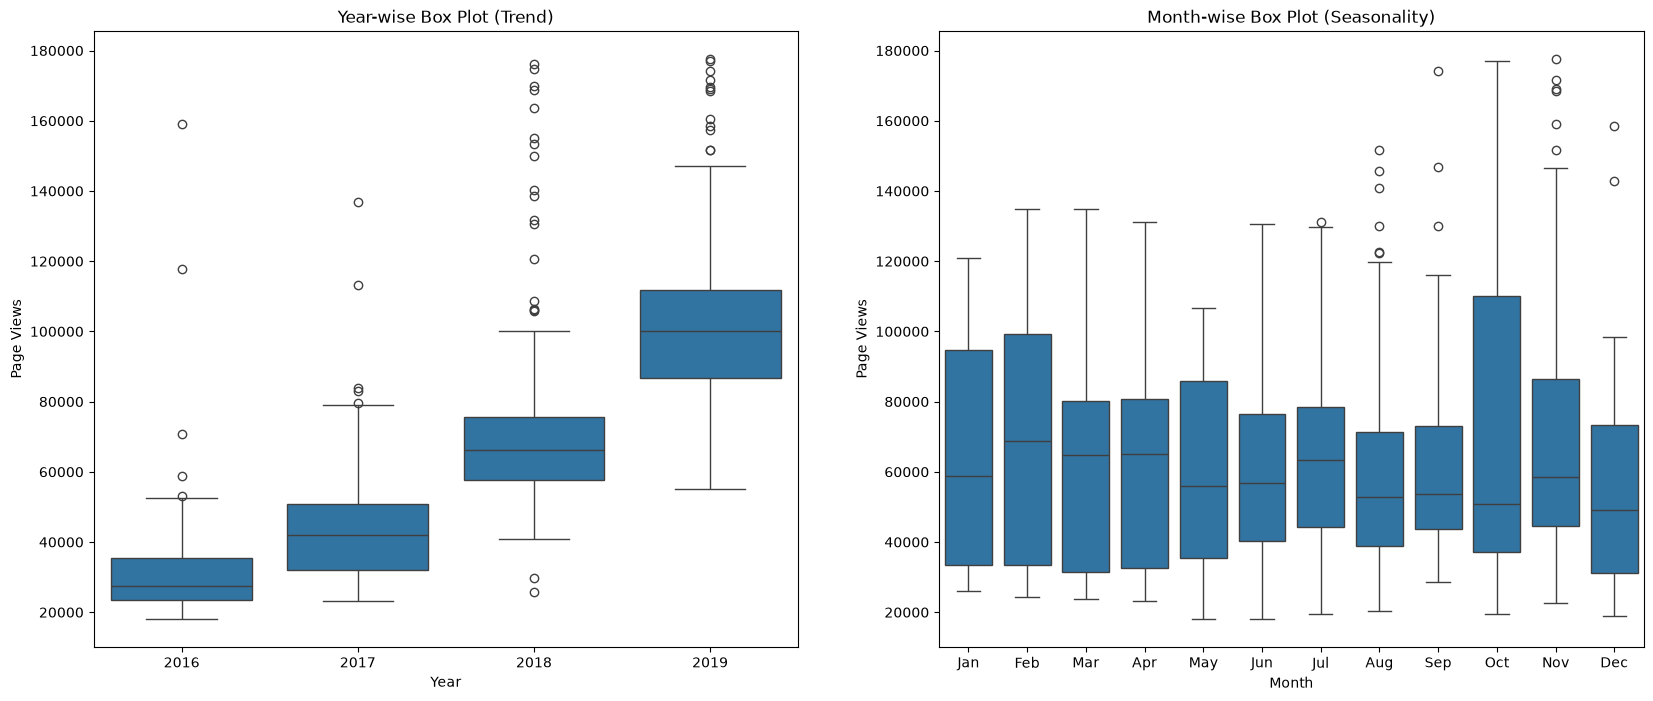

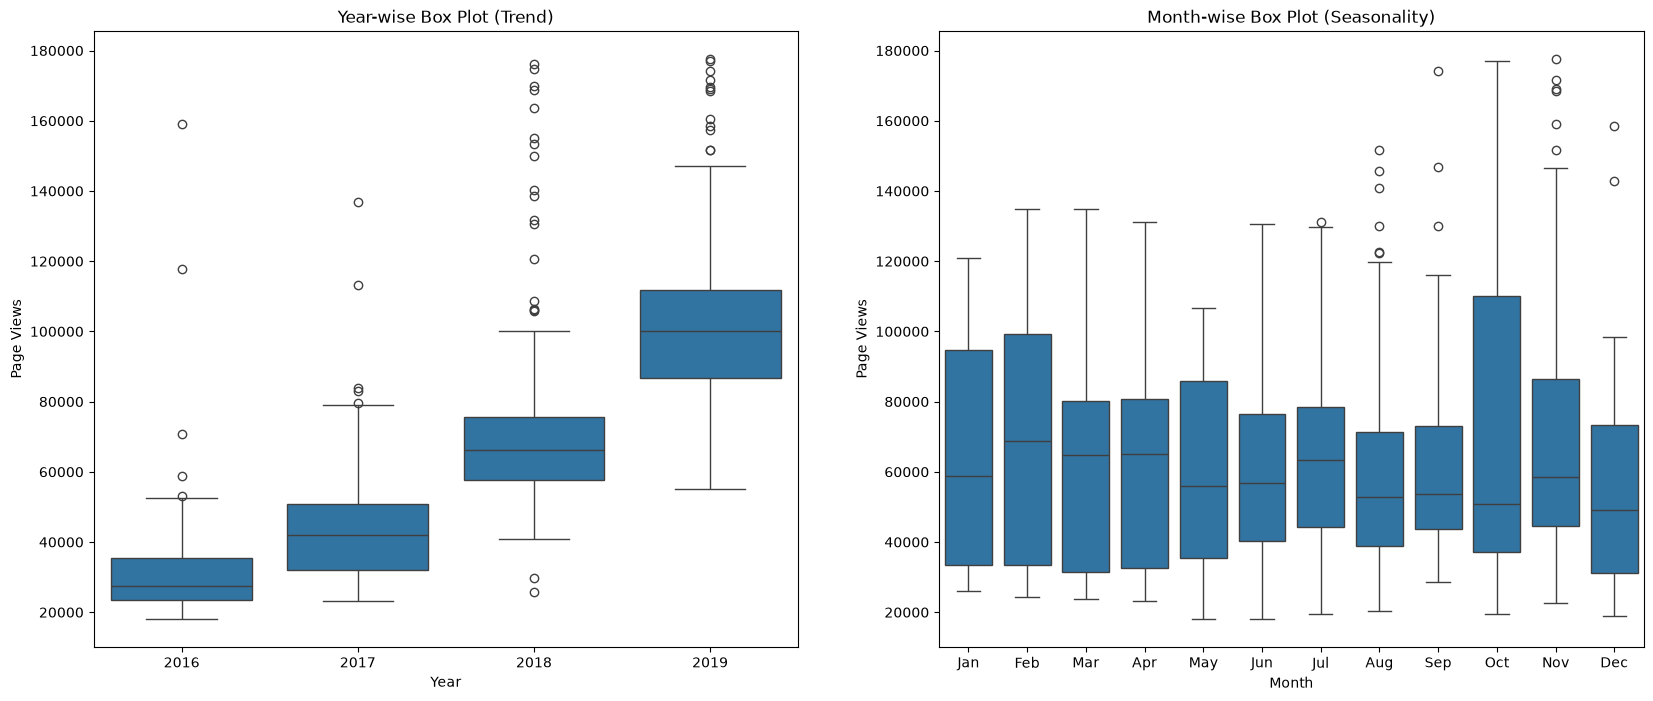

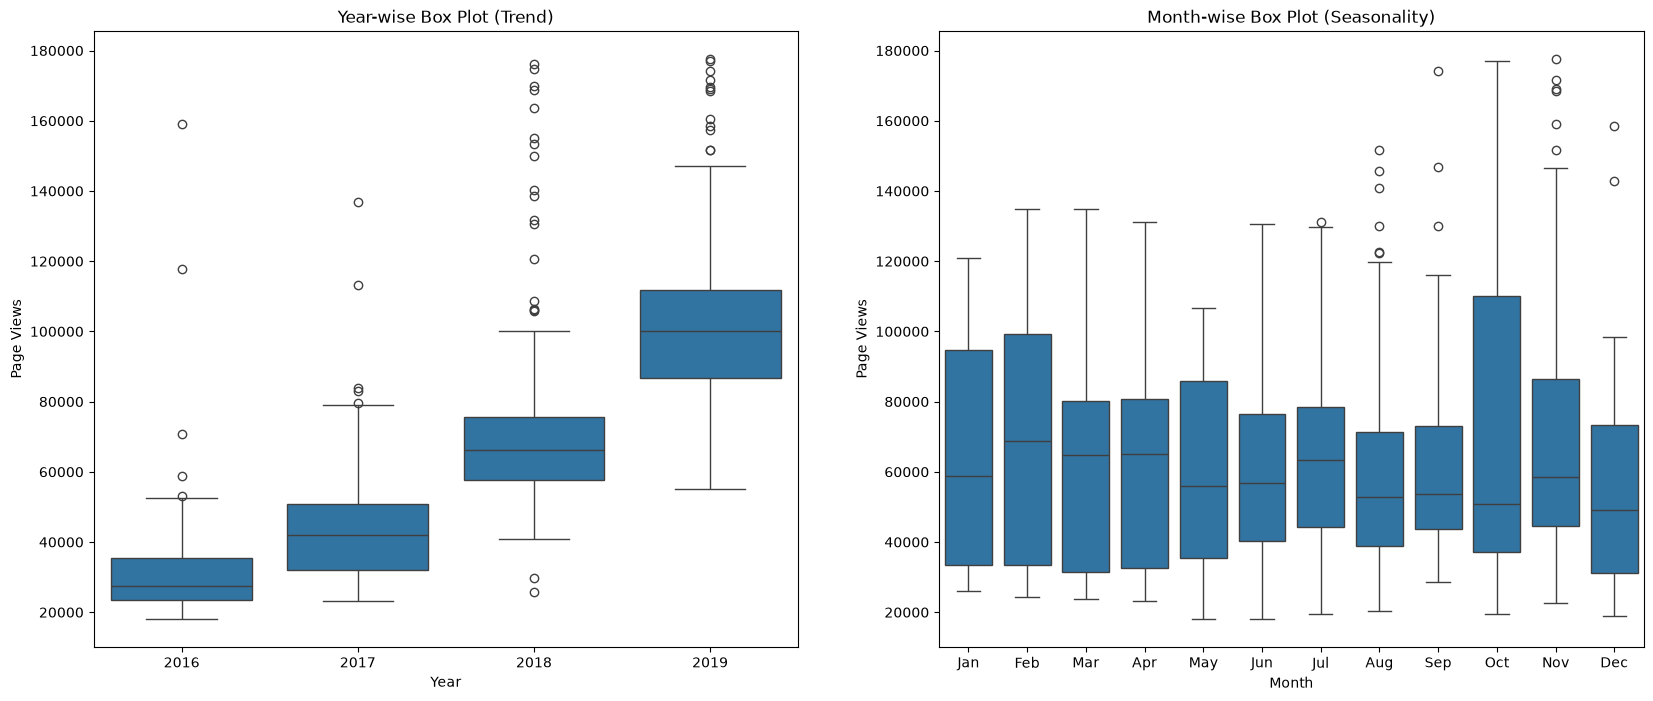

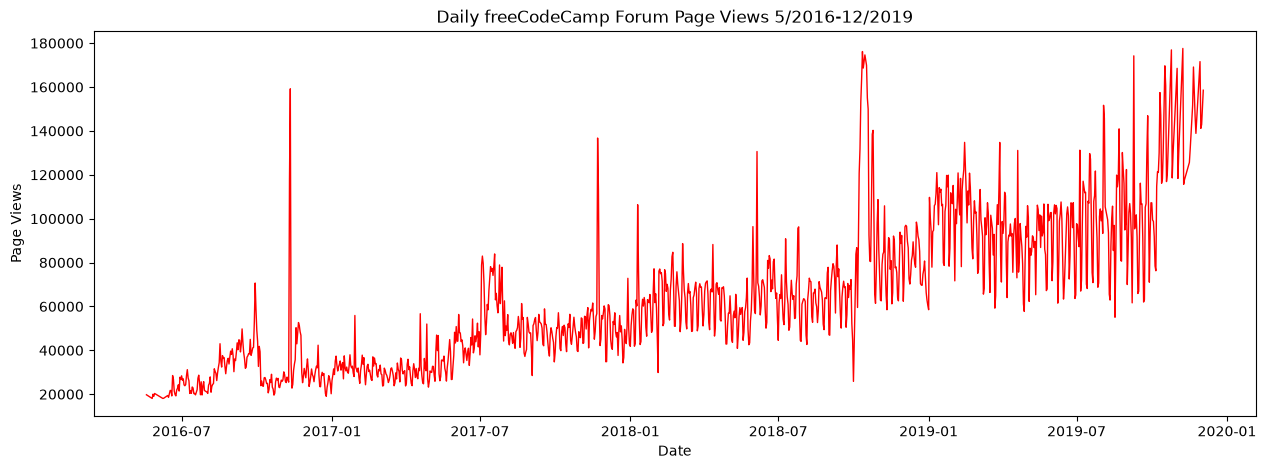

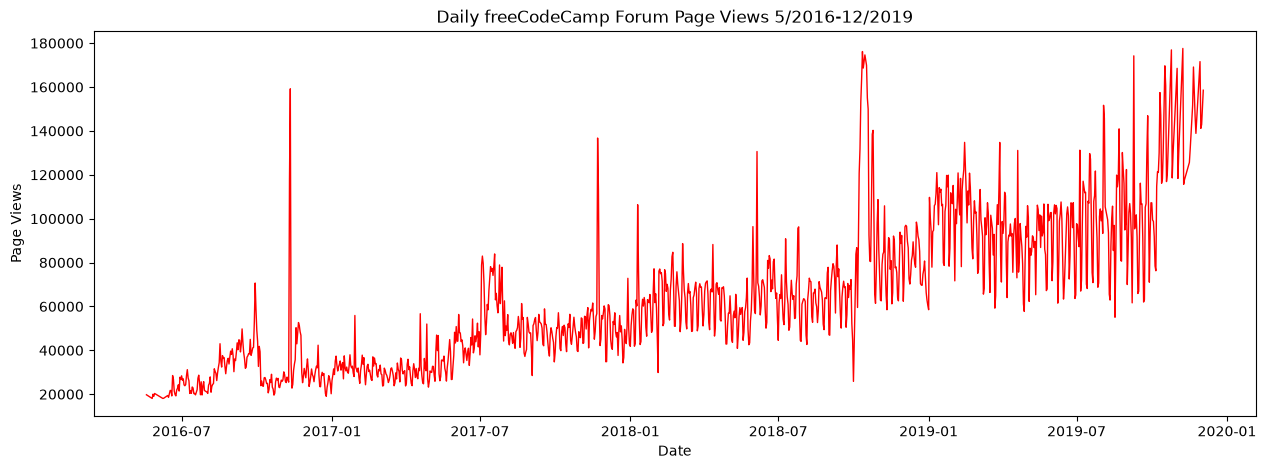

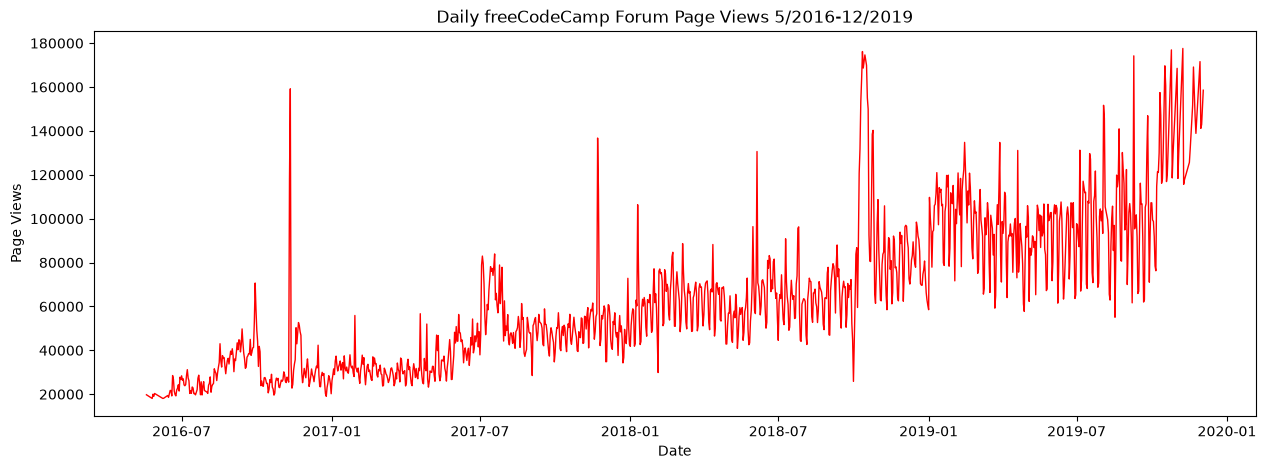

In [6]:
# Final Cell: Integration Test Runner
import unittest
import test_module

suite = unittest.defaultTestLoader.loadTestsFromModule(test_module)
runner = unittest.TextTestRunner(verbosity=2)
result = runner.run(suite)
assert result.wasSuccessful(), 'Time Series Visualizer unit tests failed!'
print('\nAll 11 integration tests passed successfully!')